In [95]:
print('Hello world')

Hello world


In [96]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from joblib import Parallel, delayed
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
import scipy.stats as stats
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, LabelEncoder,PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [97]:
df_2022=pd.read_csv('fifa_ranking_2022-10-06.csv')
df_2026=pd.read_csv('fifa_ranking_2026-06-08.csv')
df_matches=pd.read_csv('matches_1930_2022.csv')
df_shedule=pd.read_csv('schedule_2026.csv')
df_world_cup=pd.read_csv('world_cup.csv')
df=pd.DataFrame()


In [98]:
#trying to find total teams from 1930 to 2022
match_teams = set(df_matches['home_team'].dropna().unique()).union(set(df_matches['away_team'].dropna().unique()))

# total teams in 2022 
ranking_teams = set(df_2022['team'].dropna().unique())

# team that are not in 2022 bit were there in btw 1930 to 2022
missing_in_rankings = sorted(list(match_teams - ranking_teams))

print(f"Total unique teams in Matches: {len(match_teams)}")
print(f"Total unique teams in Rankings: {len(ranking_teams)}")
print(f"Number of mismatches: {len(missing_in_rankings)}")
print("Mismatched Teams:", missing_in_rankings)

Total unique teams in Matches: 86
Total unique teams in Rankings: 211
Number of mismatches: 11
Mismatched Teams: ['Czech Republic', 'Czechoslovakia', 'Dutch East Indies', 'FR Yugoslavia', 'Germany DR', 'Serbia and Montenegro', 'Soviet Union', 'United States', 'West Germany', 'Yugoslavia', 'Zaire']


In [99]:
missing_in_rankings

['Czech Republic',
 'Czechoslovakia',
 'Dutch East Indies',
 'FR Yugoslavia',
 'Germany DR',
 'Serbia and Montenegro',
 'Soviet Union',
 'United States',
 'West Germany',
 'Yugoslavia',
 'Zaire']

In [100]:
country_mapping = {
    'United States': 'USA',
    'Czech Republic': 'Czechia',
    'Czechoslovakia': 'Czechia',
    'Dutch East Indies': 'Indonesia',
    'FR Yugoslavia': 'Serbia',
    'Germany DR': 'Germany',
    'Serbia and Montenegro': 'Serbia',
    'Soviet Union': 'Russia',
    'West Germany': 'Germany',
    'Yugoslavia': 'Serbia',
    'Zaire': 'Congo DR'
}

df_matches['home_team'] = df_matches['home_team'].replace(country_mapping)
df_matches['away_team'] = df_matches['away_team'].replace(country_mapping)

In [101]:
df_matches.isnull().sum()

home_team                            0
away_team                            0
home_score                           0
home_xg                            836
home_penalty                       929
away_score                           0
away_xg                            836
away_penalty                       929
home_manager                         0
home_captain                       320
away_manager                         0
away_captain                       320
Attendance                           0
Venue                                0
Officials                          255
Round                                0
Date                                 0
Score                                0
Referee                            255
Notes                              891
Host                                 0
Year                                 0
home_goal                          246
away_goal                          393
home_goal_long                     246
away_goal_long           

In [102]:
important_features = [
    'home_team','away_team','home_score','away_score',
    'home_xg','away_xg','Round','Year','Host','Attendance','Venue',
    'home_penalty','away_penalty','home_red_card','away_red_card',
    'home_yellow_red_card','away_yellow_red_card',
    'home_penalty_goal','away_penalty_goal',
    'Date']

In [86]:
hell=[]
for i in df_matches.columns:
    x=(df_matches[i].isnull().sum())
   
    if x <300:
        hell.append(i)
    

In [103]:
print(df_matches['home_penalty'].value_counts(dropna=False))
print(df_matches['away_penalty'].value_counts(dropna=False))

home_penalty
NaN    929
3.0     13
4.0     11
5.0      5
1.0      3
2.0      2
0.0      1
Name: count, dtype: int64
away_penalty
NaN    929
3.0     11
4.0     10
2.0      9
5.0      3
0.0      1
1.0      1
Name: count, dtype: int64


In [71]:
#
# We check if 'home_penalty' is NOT null. If it's not null, a shootout happened.
df_matches['went_to_shootout'] = df_matches['home_penalty'].notna().astype(int)
df_matches['home_penalty'] = df_matches['home_penalty'].fillna(0)
df_matches['away_penalty'] = df_matches['away_penalty'].fillna(0)


# Assuming 'df' is your DataFrame and 'your_column' is the column name
df_matches['home_red_card'] = df_matches['home_red_card'].notna().astype(int)
df_matches['away_red_card'] = df_matches['away_red_card'].notna().astype(int)
df_matches['home_yellow_red_card'] = df_matches['home_red_card'].notna().astype(int)
df_matches['away_yellow_red_card'] = df_matches['home_red_card'].notna().astype(int)
df_matches['away_own_goal'] = df_matches['away_own_goal'].notna().astype(int)
df_matches['home_own_goal'] = df_matches['home_own_goal'].notna().astype(int)


In [88]:
df_matches['home_own_goal'].isnull().sum()

np.int64(925)

In [89]:
x2=pd.DataFrame(df_matches['Score'])
x2


,Score
0,(4) 3–3 (2)
1,2–1
2,2–0
3,3–0
4,1–0
...,...
959,1–0
960,2–1
961,3–1
962,3–0


In [ ]:
features = [
'home_team',
'away_team',
'home_xg',
'away_xg',
'Round',
'Host',
'Attendance',
'Venue',
'Date',
'home_manager',
'away_manager'
'home_avg_goals',
'away_avg_gaols'
'refree'

]

In [91]:
df_matches['away_manager'].isnull().sum()

np.int64(0)

In [16]:
df_matches['Year']

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
959    1930
960    1930
961    1930
962    1930
963    1930
Name: Year, Length: 964, dtype: int64

 ## Rounds where a draw is allowed
draw_rounds = [
   'Group stage',
    'First group stage',
    'Second group stage']
#
def get_match_result(row):
    # Normal time / Extra time result
    if row['home_score'] > row['away_score']:
          return 'Home Win'
    elif row['home_score'] < row['away_score']:
       return 'Away Win'
    # Scores are equal
    else:
        # Draw is allowed in these rounds
        if row['Round'] in draw_rounds:
            return 'Draw'
        # Knockout rounds -> decide by penalties
        else:
            if pd.notna(row['home_penalty']) and pd.notna(row['away_penalty']):
                if row['home_penalty'] > row['away_penalty']:
                    return 'Home Win'
                elif row['home_penalty'] < row['away_penalty']:
                    return 'Away Win'
            #If penalty data is unavailable
            return 'Draw'


 #Create the new column
df_matches['Match_Result'] = df_matches.apply(get_match_result, axis=1)

 #Check the result distribution
print(df_matches['Match_Result'].value_counts())

technically we should use the above code for our model because many rounds can have a draw like group stage  and many rounds can't have a draw like final etc . but we will use the below logic for simlicity 

In [104]:
import numpy as np

df_matches['Match_Result'] = np.where(
    df_matches['home_score'] > df_matches['away_score'], 0,
    np.where(
        df_matches['home_score'] < df_matches['away_score'], 1,
        2
    )
)

In [105]:
train_data = df_matches[df_matches['Year'] <= 2018].copy()
test_data = df_matches[df_matches['Year'] == 2022].copy()

change the datatype of date in starting

In [106]:
df_matches['Date'].info()

<class 'pandas.Series'>
RangeIndex: 964 entries, 0 to 963
Series name: Date
Non-Null Count  Dtype
--------------  -----
964 non-null    str  
dtypes: str(1)
memory usage: 7.7 KB


In [107]:
home_goals = train_data[['home_team', 'home_score']].rename(
    columns={'home_team': 'team', 'home_score': 'goals_scored'}
)

away_goals = train_data[['away_team', 'away_score']].rename(
    columns={'away_team': 'team', 'away_score': 'goals_scored'}
)

all_goals = pd.concat([home_goals, away_goals], ignore_index=True)

team_avg_goals = all_goals.groupby('team')['goals_scored'].mean()

train_data['home_avg_goals'] = train_data['home_team'].map(team_avg_goals)
train_data['away_avg_goals'] = train_data['away_team'].map(team_avg_goals)
test_data['home_avg_goals'] = test_data['home_team'].map(team_avg_goals)
test_data['away_avg_goals'] = test_data['away_team'].map(team_avg_goals)

overall_avg = all_goals['goals_scored'].mean()

train_data[['home_avg_goals', 'away_avg_goals']] = (
    train_data[['home_avg_goals', 'away_avg_goals']].fillna(overall_avg)
)

test_data[['home_avg_goals', 'away_avg_goals']] = (
    test_data[['home_avg_goals', 'away_avg_goals']].fillna(overall_avg)
)


below iss  the code which makes a new feature that has the data the team has played how many world cup 
matches more the no. of matches played more the experinced the team is and more likely the chances to win 

In [108]:
import pandas as pd

# 1. Isolate the Years and Teams from the historical training data (1930 - 2018)
home_years = train_data[['Year', 'home_team']].rename(columns={'home_team': 'team'})
away_years = train_data[['Year', 'away_team']].rename(columns={'away_team': 'team'})

# 2. Combine them and drop duplicates
# A team plays multiple matches in a single World Cup, so we drop duplicates 
# to ensure we only count '1' appearance per tournament year.
all_appearances = pd.concat([home_years, away_years]).drop_duplicates()

# 3. Count the unique years for each team to get their Total Experience
world_cup_experience = all_appearances.groupby('team')['Year'].count()

# 4. Map the experience back to the Training Data
train_data['home_wc_experience'] = train_data['home_team'].map(world_cup_experience)
train_data['away_wc_experience'] = train_data['away_team'].map(world_cup_experience)

# 5. Map the experience back to the Testing Data (2022)
test_data['home_wc_experience'] = test_data['home_team'].map(world_cup_experience)
test_data['away_wc_experience'] = test_data['away_team'].map(world_cup_experience)

# 6. Handle the Debuting Teams (Like Qatar!)
# If a team isn't in the 1930-2018 data, they have 0 prior experience.
# Unlike the 'average goals' feature, filling with 0 is mathematically perfect here!
train_data[['home_wc_experience', 'away_wc_experience']] = (
    train_data[['home_wc_experience', 'away_wc_experience']].fillna(0)
)
test_data[['home_wc_experience', 'away_wc_experience']] = (
    test_data[['home_wc_experience', 'away_wc_experience']].fillna(0)
)

if the team play in their homeground they have advantage as htey are familiar to the ground and the crowd support also matters so if the team is playing in homeground they have advantage and are give more importance as multiplied with the crowd though all the crowd will not support only that team but as the attendee increases their support in the homeground will also increase 

In [109]:

train_data['home_is_host'] = (train_data['home_team'] == train_data['Host']).astype(int)
train_data['away_is_host'] = (train_data['away_team'] == train_data['Host']).astype(int)

test_data['home_is_host'] = (test_data['home_team'] == test_data['Host']).astype(int)
test_data['away_is_host'] = (test_data['away_team'] == test_data['Host']).astype(int)

train_data['home_adrenaline_boost'] = train_data['home_is_host'] * train_data['Attendance']
train_data['away_adrenaline_boost'] = train_data['away_is_host'] * train_data['Attendance']

test_data['home_adrenaline_boost'] = test_data['home_is_host'] * test_data['Attendance']
test_data['away_adrenaline_boost'] = test_data['away_is_host'] * test_data['Attendance']

train_data[['home_adrenaline_boost', 'away_adrenaline_boost']] = (
    train_data[['home_adrenaline_boost', 'away_adrenaline_boost']].fillna(0)
)

test_data[['home_adrenaline_boost', 'away_adrenaline_boost']] = (
    test_data[['home_adrenaline_boost', 'away_adrenaline_boost']].fillna(0)
)


In [110]:
print(df_matches['home_manager'].isnull().sum())
print(df_matches['away_manager'].isnull().sum())
print(df_matches['home_captain'].isnull().sum())
print(df_matches['away_captain'].isnull().sum())
print(df_matches['home_captain'].nunique())
print(df_matches['away_captain'].nunique())

0
0
320
320
280
334


In [111]:
df_matches['away_xg'].isnull().sum()

np.int64(836)

In [112]:
xg_status = df_matches.groupby('Year').agg(
    Home_XG_All_Missing=('home_xg', lambda x: x.isna().all()),
    Away_XG_All_Missing=('away_xg', lambda x: x.isna().all())
)

print(xg_status)

      Home_XG_All_Missing  Away_XG_All_Missing
Year                                          
1930                 True                 True
1934                 True                 True
1938                 True                 True
1950                 True                 True
1954                 True                 True
1958                 True                 True
1962                 True                 True
1966                 True                 True
1970                 True                 True
1974                 True                 True
1978                 True                 True
1982                 True                 True
1986                 True                 True
1990                 True                 True
1994                 True                 True
1998                 True                 True
2002                 True                 True
2006                 True                 True
2010                 True                 True
2014         

In [113]:
x=pd.DataFrame(df_matches.info())


<class 'pandas.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    str    
 1   away_team                        964 non-null    str    
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    str    
 9   home_captain                     644 non-null    str    
 10  away_manager                     964 non-null    str    
 11  away_captain                     644 non-null    str    
 12  Attendance                       

In [116]:
import pandas as pd

# 1. Ensure the Date column is a proper datetime object so the .days math works
train_data['Date'] = pd.to_datetime(train_data['Date'])
test_data['Date'] = pd.to_datetime(test_data['Date'])

# 2. Wrap your exact logic in a function to apply it independently
def calculate_rest_days_iterative(df):
    # CRITICAL: Sort chronologically so the for-loop reads time linearly
    df = df.sort_values(by=['Date']).copy()
    
    last_match_date = {}
    home_rest_days = []
    away_rest_days = []
    
    for idx, row in df.iterrows():
        date = row['Date']
        home = row['home_team']
        away = row['away_team']
        year = row['Year']
        
        # Create a unique key for the team IN THAT SPECIFIC YEAR
        # This prevents 1,460 day gaps between different World Cups!
        home_key = f"{home}_{year}"
        away_key = f"{away}_{year}"
        
        # Home team rest
        if home_key in last_match_date:
            home_rest = (date - last_match_date[home_key]).days
        else:
            home_rest = 7 # Your default for the first match of the tournament
            
        # Away team rest
        if away_key in last_match_date:
            away_rest = (date - last_match_date[away_key]).days
        else:
            away_rest = 7
            
        home_rest_days.append(home_rest)
        away_rest_days.append(away_rest)
        
        # Update last match dates
        last_match_date[home_key] = date
        last_match_date[away_key] = date
        
    # Assign the lists back to the dataframe
    df['home_rest_days'] = home_rest_days
    df['away_rest_days'] = away_rest_days
    df['rest_difference'] = df['home_rest_days'] - df['away_rest_days']
    
    return df

# 3. Apply your function to the training and testing sets
train_data = calculate_rest_days_iterative(train_data)
test_data = calculate_rest_days_iterative(test_data)

# Print a quick check to verify the rest_difference calculation worked
print(train_data[['Date', 'home_team', 'away_team', 'rest_difference']].head())

          Date  home_team away_team  rest_difference
963 1930-07-13     France    Mexico                0
962 1930-07-13        USA   Belgium                0
960 1930-07-14     Serbia    Brazil                0
961 1930-07-14    Romania      Peru                0
959 1930-07-15  Argentina    France                5


In [100]:
for i in df_matches.columns:
    if df_matches[i].isnull().sum() >800:
        print(i)

home_xg
away_xg
Notes
home_own_goal
away_own_goal
home_penalty_goal
away_penalty_goal
home_penalty_miss_long
away_penalty_miss_long
home_penalty_shootout_goal_long
away_penalty_shootout_goal_long
home_penalty_shootout_miss_long
away_penalty_shootout_miss_long
home_red_card
away_red_card
home_yellow_red_card
away_yellow_red_card


In [118]:
print(df_matches['home_yellow_red_card'].isnull().sum())
print(df_matches['away_yellow_red_card'].min())
print(df_matches['away_goal'].isnull().sum())
print(df_matches['away_red_card'].min())
print(df_matches['home_red_card'].isnull().sum())

941
Albert Nađ · 45+1
393
Américo Gallego · 84
913


In [119]:
df_matches['away_red_card'].sample(10)

951    NaN
778    NaN
631    NaN
218    NaN
840    NaN
83     NaN
42     NaN
574    NaN
648    NaN
473    NaN
Name: away_red_card, dtype: str

In [120]:
import pandas as pd

# Count missing values
missing_values = df_matches.isnull().sum()

# Calculate percentage
missing_percentage = (missing_values / len(df_matches)) * 100

# Create summary dataframe
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display columns having missing values only
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

# Sort in descending order
missing_summary = missing_summary.sort_values(by='Percentage (%)', ascending=False)

print(missing_summary)

                                 Missing Values  Percentage (%)
home_penalty_miss_long                      958       99.377593
away_penalty_miss_long                      955       99.066390
away_own_goal                               947       98.236515
home_yellow_red_card                        941       97.614108
home_penalty_shootout_miss_long             940       97.510373
away_penalty_shootout_miss_long             934       96.887967
away_yellow_red_card                        933       96.784232
home_penalty_shootout_goal_long             930       96.473029
away_penalty_shootout_goal_long             930       96.473029
away_penalty                                929       96.369295
home_penalty                                929       96.369295
home_own_goal                               925       95.954357
home_red_card                               913       94.709544
away_red_card                               910       94.398340
Notes                                   

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10344\1056239866.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


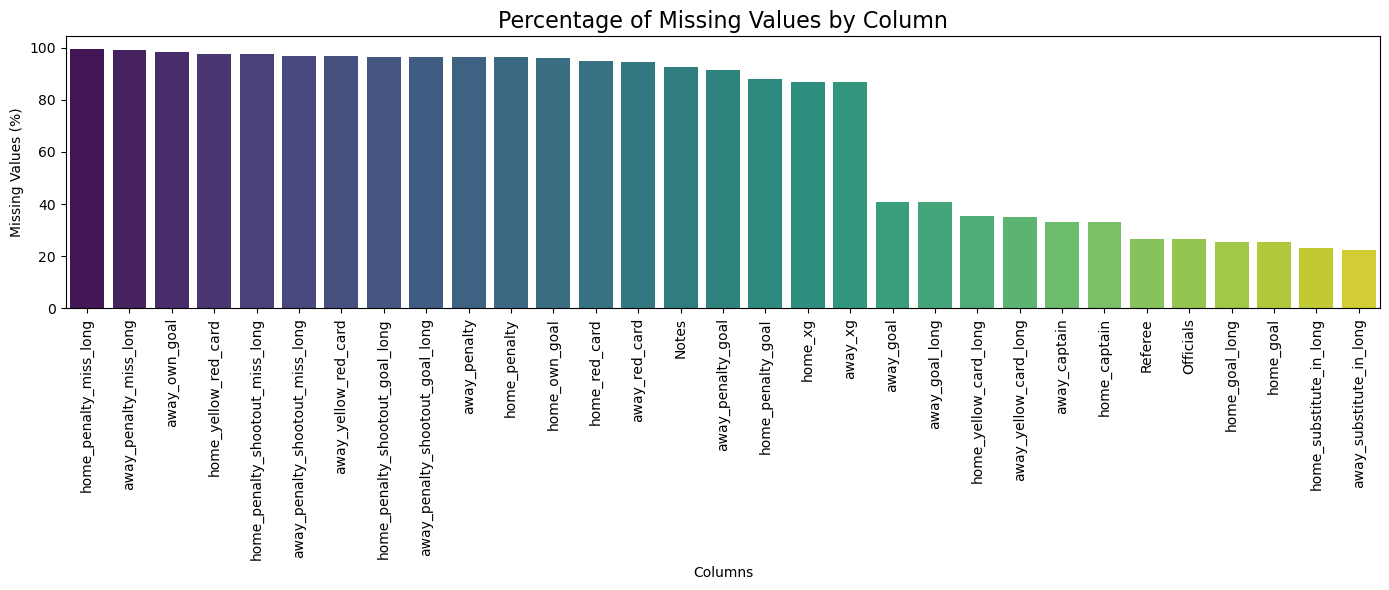

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary['Percentage (%)'],
    palette='viridis'
)

plt.title("Percentage of Missing Values by Column", fontsize=16)
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [48]:
x3=df_matches.groupby('home_team')['home_captain']

In [49]:
pd.DataFrame(x3)

,0,1
0,Algeria,147 NaN 248 Na...
1,Angola,"314 NaN Name: home_captain, dtype: str"
2,Argentina,0 Lionel Messi 3 L...
3,Australia,24 Mathew Ryan 88 Mile Jedinak 156 ...
4,Austria,524 Toni Polster 534 Toni Polster ...
...,...,...
70,USA,62 Tyler Adams 144 ...
71,Ukraine,"273 NaN Name: home_captain, dtype: str"
72,United Arab Emirates,"548 Fahad Khamees Name: home_captain, dtype..."
73,Uruguay,49 Diego Godín 70 Diego ...


In [56]:
is_present = (df_matches['home_captain'] == 'Gareth Bale').any()
print(is_present)


False


In [42]:
df_matches['Officials'].iloc[252]


nan

In [146]:
df_matches['home_substitute_in_long' \
'' \
''].sample(20)

351    ['53&rsquor;|0:1|Patrick Suffo|for Bill Tchato...
122    ['62&rsquor;|0:1|Paolo Guerrero|for Edison Flo...
781                                                  NaN
685    ['64&rsquor;|1:1|Norberto Alonso|for José Dani...
490    ['75&rsquor;|2:0|Aldair|for Ricardo Rocha', '8...
785                                                  NaN
673                                                  NaN
504       ['82&rsquor;|1:0|Andreas Möller|for Uwe Bein']
21     ['64&rsquor;|0:0|Bruno Petković|for Marko Liva...
247    ['46&rsquor;|0:1|Federico Marchetti|for Gianlu...
183    ['46&rsquor;|1:0|Gonzalo Higuaín|for Maxi Rodr...
568    ['70&rsquor;|0:0|Charlie Nicholas', '70&rsquor...
847                                                  NaN
220    ['46&rsquor;|0:1|Pablo Barrera|for Andrés Guar...
773                                                  NaN
815                                                  NaN
932                                                  NaN
168    ['46&rsquor;|1:1|Juan Ca

In [ ]:
import pandas as pd

# 1. Create a flag for matches that went to a shootout in the HISTORICAL data.
# If 'home_penalty' has data (not null), the match went to a shootout.
train_data['is_shootout'] = train_data['home_penalty'].notna().astype(int)

# 2. Isolate the teams and the shootout flag
home_shootouts = train_data[['home_team', 'is_shootout']].rename(columns={'home_team': 'team'})
away_shootouts = train_data[['away_team', 'is_shootout']].rename(columns={'away_team': 'team'})

# 3. Combine them to calculate the total historical shootout experience per team
all_shootouts = pd.concat([home_shootouts, away_shootouts])
team_shootout_experience = all_shootouts.groupby('team')['is_shootout'].sum()

# 4. Map the experience back to the Training Data
train_data['home_shootout_exp'] = train_data['home_team'].map(team_shootout_experience)
train_data['away_shootout_exp'] = train_data['away_team'].map(team_shootout_experience)

# 5. Map the experience back to the Testing Data (2022)
test_data['home_shootout_exp'] = test_data['home_team'].map(team_shootout_experience)
test_data['away_shootout_exp'] = test_data['away_team'].map(team_shootout_experience)

# 6. Handle Missing Values (Zero Experience)
# If a team has never been in a shootout (or is a debuting team), their experience is factually 0.
train_data[['home_shootout_exp', 'away_shootout_exp']] = (
    train_data[['home_shootout_exp', 'away_shootout_exp']].fillna(0)
)
test_data[['home_shootout_exp', 'away_shootout_exp']] = (
    test_data[['home_shootout_exp', 'away_shootout_exp']].fillna(0)
)

In [76]:
hell=[]
for i in df_matches.columns:
    hell.append(i)

for i in range(20,41):
    print(hell[i])

Host
Year
home_goal
away_goal
home_goal_long
away_goal_long
home_own_goal
away_own_goal
home_penalty_goal
away_penalty_goal
home_penalty_miss_long
away_penalty_miss_long
home_penalty_shootout_goal_long
away_penalty_shootout_goal_long
home_penalty_shootout_miss_long
away_penalty_shootout_miss_long
home_red_card
away_red_card
home_yellow_red_card
away_yellow_red_card
home_yellow_card_long


In [77]:
df_matches['home_red_card']

0      1
1      1
2      1
3      1
4      1
      ..
959    1
960    1
961    1
962    1
963    1
Name: home_red_card, Length: 964, dtype: int64

In [ ]:
import pandas as pd

# 1. Calculate a 'Recklessness Score' for each match in the historical training data.
# We add the binary flags together. A team getting a yellow AND a red gets a higher score.
train_data['home_match_card_score'] = (
    train_data['home_red_card'].notna().astype(int) +
    train_data['home_yellow_red_card'].notna().astype(int) +
    train_data['home_yellow_card_long'].notna().astype(int)
)

train_data['away_match_card_score'] = (
    train_data['away_red_card'].notna().astype(int) +
    train_data['away_yellow_red_card'].notna().astype(int) +
    train_data['away_yellow_card_long'].notna().astype(int)
)

# 2. Isolate the teams and their match scores
home_cards = train_data[['home_team', 'home_match_card_score']].rename(
    columns={'home_team': 'team', 'home_match_card_score': 'card_score'}
)
away_cards = train_data[['away_team', 'away_match_card_score']].rename(
    columns={'away_team': 'team', 'away_match_card_score': 'card_score'}
)

# 3. Combine them to calculate the historical average per team
all_cards = pd.concat([home_cards, away_cards])
team_discipline_score = all_cards.groupby('team')['card_score'].mean()

# 4. Map the Discipline Score back to the Training Data
train_data['home_discipline_score'] = train_data['home_team'].map(team_discipline_score)
train_data['away_discipline_score'] = train_data['away_team'].map(team_discipline_score)

# 5. Map the Discipline Score back to the Testing Data (2022)
test_data['home_discipline_score'] = test_data['home_team'].map(team_discipline_score)
test_data['away_discipline_score'] = test_data['away_team'].map(team_discipline_score)

# 6. Handle the Debuting Teams (Missing Values)
# Unlike shootout experience (where 0 was factual), a new team WILL commit fouls.
# Therefore, we fill debuting teams with the Global Average discipline score!
global_avg_discipline = team_discipline_score.mean()

train_data[['home_discipline_score', 'away_discipline_score']] = (
    train_data[['home_discipline_score', 'away_discipline_score']].fillna(global_avg_discipline)
)
test_data[['home_discipline_score', 'away_discipline_score']] = (
    test_data[['home_discipline_score', 'away_discipline_score']].fillna(global_avg_discipline)
)